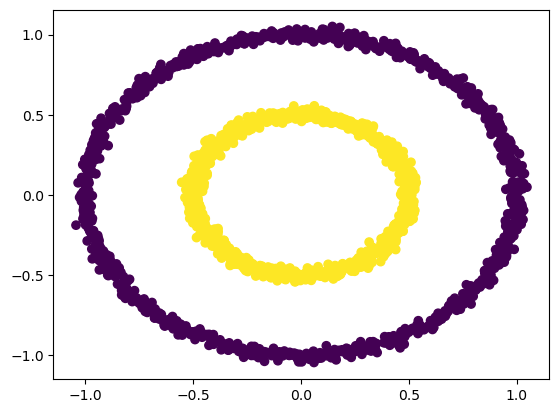

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import torch
import sklearn
import seaborn as sns
from sklearn.datasets import make_circles
 
X, y = make_circles(n_samples=2000, noise=0.02, factor=0.5)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

<Axes: >

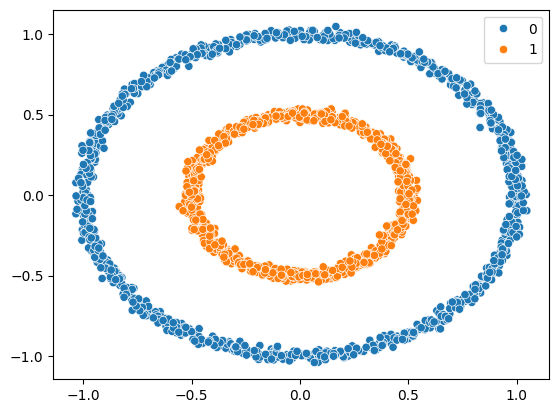

In [2]:
sns.scatterplot(x=X[:, 0], y=X[:, 1],hue=y)

In [3]:
device =  'cuda' if torch.cuda.is_available() else 'cpu'
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.long).to(device)
y_tensor = y_tensor.unsqueeze(1).float().to(device)

 

In [4]:
from sklearn.model_selection import train_test_split
torch.manual_seed(42)
X_train,X_test,y_train,y_test = train_test_split(X_tensor,y_tensor,test_size=0.2,random_state=42)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

In [72]:
from torch import nn
torch.manual_seed(42)

class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
            
        )

    def forward(self, x):
        return self.model(x)
        
    

## Train the model

Epoch 0, Loss: 0.688879
Epoch 50, Loss: 0.688129
Epoch 100, Loss: 0.687426
Epoch 150, Loss: 0.686749
Epoch 200, Loss: 0.686086
Epoch 250, Loss: 0.685443
Epoch 300, Loss: 0.684810
Epoch 350, Loss: 0.684170
Epoch 400, Loss: 0.683516
Epoch 450, Loss: 0.682842
Epoch 500, Loss: 0.682143
Epoch 550, Loss: 0.681420
Epoch 600, Loss: 0.680669
Epoch 650, Loss: 0.679886
Epoch 700, Loss: 0.679070
Epoch 750, Loss: 0.678217
Epoch 800, Loss: 0.677327
Epoch 850, Loss: 0.676397
Epoch 900, Loss: 0.675424
Epoch 950, Loss: 0.674403
Epoch 1000, Loss: 0.673332
Epoch 1050, Loss: 0.672208
Epoch 1100, Loss: 0.671028
Epoch 1150, Loss: 0.669791
Epoch 1200, Loss: 0.668497
Epoch 1250, Loss: 0.667144
Epoch 1300, Loss: 0.665731
Epoch 1350, Loss: 0.664256
Epoch 1400, Loss: 0.662716
Epoch 1450, Loss: 0.661103
Epoch 1500, Loss: 0.659414
Epoch 1550, Loss: 0.657650
Epoch 1600, Loss: 0.655815
Epoch 1650, Loss: 0.653896
Epoch 1700, Loss: 0.651886
Epoch 1750, Loss: 0.649781
Epoch 1800, Loss: 0.647577
Epoch 1850, Loss: 0.6452

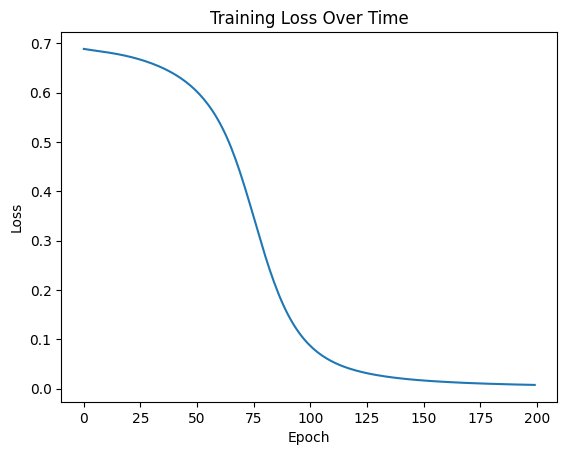

In [73]:
torch.manual_seed(42)
circle_model = CircleModel().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(circle_model.parameters(),lr=.01)
 # -----------------------------
# Training loop
# -----------------------------
losses = []
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = circle_model(X_train)
    loss = loss_fn(y_pred,y_train)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        losses.append(loss.item())
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
        
print("\n🎲🎲🎲After training:🎲🎲🎲🎲🎲")
for name, param in circle_model.named_parameters():
    print(name, param )

# Plot
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.show()    



In [74]:
circle_model.state_dict()

OrderedDict([('model.0.weight',
              tensor([[ 1.0383,  1.4230],
                      [-0.3188,  1.1566],
                      [-0.1549,  0.1427],
                      [-1.8253,  0.5895],
                      [ 0.5234, -2.1493],
                      [ 1.5376,  0.6442],
                      [ 1.1083,  0.2414],
                      [ 0.8048,  0.3234]])),
             ('model.0.bias',
              tensor([-0.0796, -0.3156, -0.3301, -0.0772, -0.1676, -0.1034, -0.0717,  1.3405])),
             ('model.2.weight',
              tensor([[-0.2791, -0.1630, -0.0998, -0.2126,  0.0334, -0.3492,  0.3193, -0.3003],
                      [ 0.9532,  0.7597, -0.1148,  1.2500,  1.3306,  1.0320,  0.5813, -0.7230],
                      [ 0.7008,  0.4495,  0.1488,  1.0666,  1.0806,  0.4585,  0.6389, -0.4288],
                      [ 0.7266,  0.1397, -0.3500,  0.0781,  0.1723,  0.7971,  0.4808,  0.2174],
                      [ 0.2114,  0.1345,  0.2767, -0.0851,  0.2344, -0.0949,  0.2138, 

### **Evaluate** the model

In [ ]:
circle_model.eval()
with torch.no_grad():
    y_logits = circle_model(X_test)
y_probs = torch.sigmoid(y_logits)
y_pred = (y_probs>0.5).int()
correct = (y_pred == y_test).sum().item()
accuracy = correct / len(y_test)

print(f"Accuracy is {accuracy:.4f}")
    

Accuracy is 0.5300


In [75]:
circle_model.eval()
with torch.no_grad():
    y_logits = circle_model(X_train)
y_probs = torch.sigmoid(y_logits)
y_pred = (y_probs>0.5).int()
correct = (y_pred == y_train).sum().item()
print(correct)
accuracy = correct / len(y_train)

print(f"Accuracy is {accuracy:.4f}")
    

1600
Accuracy is 1.0000


In [24]:
y_probs.shape

torch.Size([1600, 1])

In [54]:
y_pred

tensor([[0],
        [0],
        [1],
        ...,
        [1],
        [0],
        [0]], dtype=torch.int32)

In [79]:
circle_model.eval()

with torch.no_grad():
    y_logits = circle_model(X_test)
    y_probs = torch.round(torch.sigmoid(y_logits))
    y_pred = (y_probs > 0.5).int()

correct = (y_pred == y_test).sum().item()
accuracy = correct / len(y_test)

print(f"Accuracy is {accuracy:.4f}")

Accuracy is 1.0000


In [ ]:
print(y_pred.unique())
print(y_test.unique())

tensor([0, 1], device='cuda:0', dtype=torch.int32)
tensor([0., 1.], device='cuda:0')


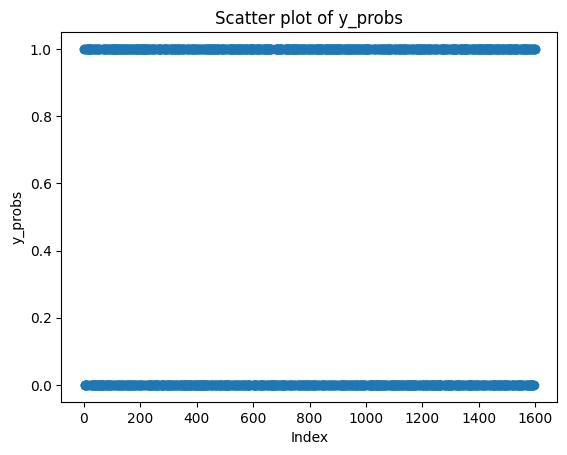

In [38]:
import torch
import matplotlib.pyplot as plt

# assuming y_probs is your tensor
y = y_probs.squeeze().cpu().detach().numpy()  # shape (1600,)
y_logits_squeeze = y_logits.squeeze().cpu().detach().numpy()  # shape (1600,)

x = range(len(y))  # 0 to 1599

plt.scatter( x,y<0.5)
plt.xlabel("Index")
plt.ylabel("y_probs")
plt.title("Scatter plot of y_probs")
plt.show()

In [77]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = y_test.cpu().numpy().squeeze()
y_hat = y_pred.cpu().numpy().squeeze()

cm = confusion_matrix(y_true, y_hat)
print(cm)

ValueError: Found input variables with inconsistent numbers of samples: [400, 1600]

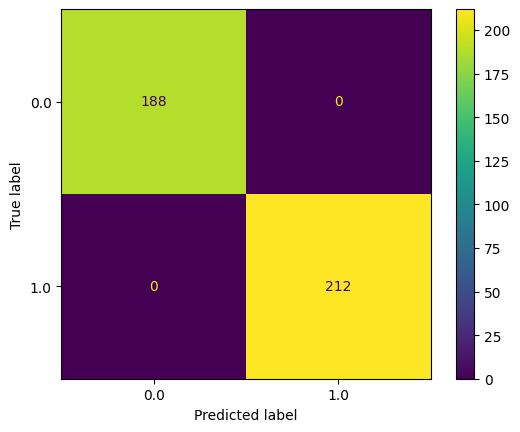

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_true, y_hat)
plt.show()

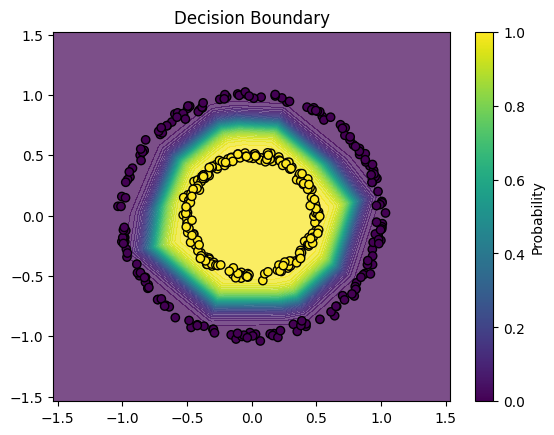

In [80]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# move data to CPU numpy
X = X_test.cpu().numpy()
y = y_test.cpu().numpy().squeeze()

# define grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

circle_model.eval()
with torch.no_grad():
    logits = circle_model(grid_tensor)
    probs = torch.sigmoid(logits)

Z = probs.reshape(xx.shape).numpy()
plt.contourf(xx, yy, Z, levels=50, alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.colorbar(label="Probability")
plt.title("Decision Boundary")
plt.show()


In [10]:
torch.linspace(0,100,2000)

tensor([0.0000e+00, 5.0025e-02, 1.0005e-01,  ..., 9.9900e+01, 9.9950e+01,
        1.0000e+02])

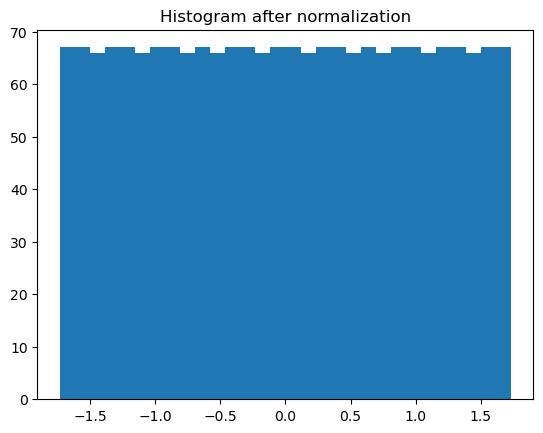

In [23]:
import torch
import matplotlib.pyplot as plt

eyad = torch.linspace(0, 100, 2000)

# normalization (standardization)
eyad_norm = (eyad - eyad.mean()) / eyad.std()

plt.hist(eyad_norm.numpy(), bins=30)
plt.title("Histogram after normalization")
plt.show()

(array([533., 477., 490., 458., 507., 504., 514., 505., 500., 512.]),
 array([4.46498394e-04, 1.00383691e-01, 2.00320885e-01, 3.00258070e-01,
        4.00195271e-01, 5.00132442e-01, 6.00069642e-01, 7.00006843e-01,
        7.99944043e-01, 8.99881244e-01, 9.99818444e-01]),
 <BarContainer object of 10 artists>)

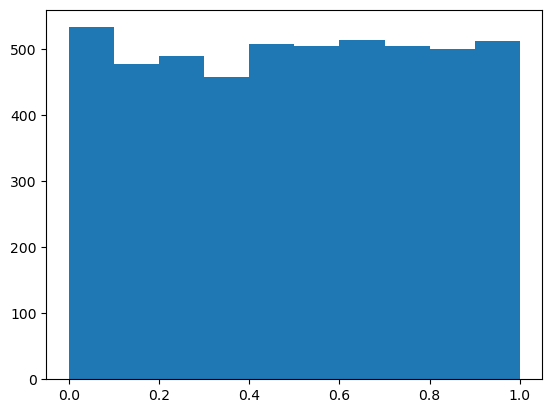

In [46]:
bell = torch.rand(5000)
plt.hist(bell.numpy())

In [47]:
import numpy as np
x = np.arange(0,100)
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

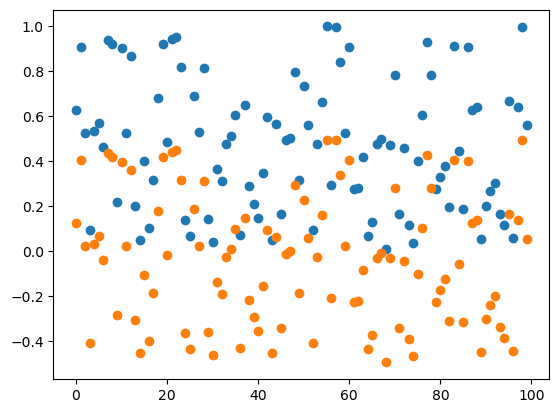

In [55]:
plt.scatter(y=bell[:100],x=x)
bell_mean  = bell - bell.mean()
plt.scatter(y=bell_mean[:100],x=x)
plt.show()

In [58]:
from torch import nn
layer = nn.Linear(10,1)
layer.weight


Parameter containing:
tensor([[ 0.1695,  0.1879, -0.0729,  0.2875,  0.0792,  0.1059,  0.0713, -0.1303,
         -0.0069, -0.2524]], requires_grad=True)

In [59]:
nn.init.xavier_uniform_(layer.weight)
layer.weight

Parameter containing:
tensor([[ 0.2309,  0.2872,  0.3219, -0.3225,  0.3949, -0.0241, -0.5895, -0.5501,
          0.0778, -0.5213]], requires_grad=True)